# Strip / Swarm Plot

Runnable example from the accompanying README. Run the code cell below to generate the chart.


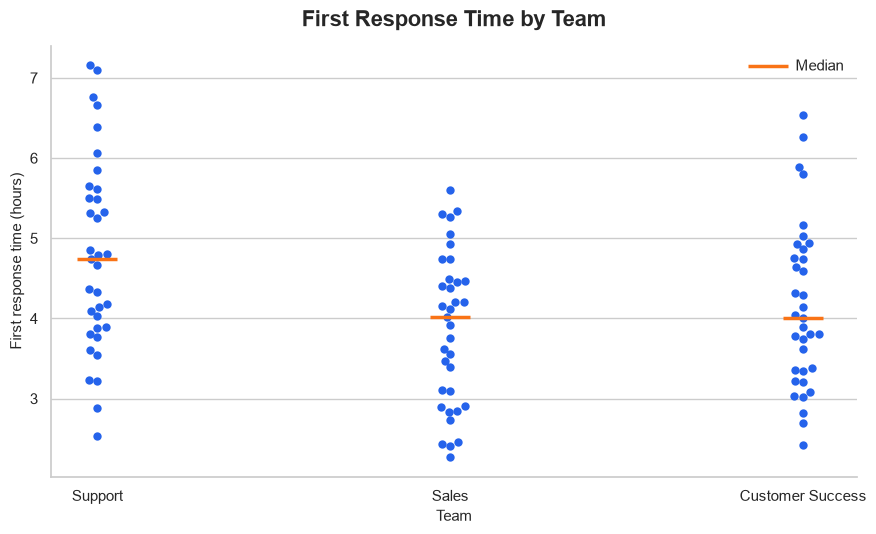

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# 1. Create reproducible sample response times, in hours, for three teams.
rng = np.random.default_rng(seed=35)
support_times = rng.normal(loc=4.8, scale=1.1, size=35)
sales_times = rng.normal(loc=3.9, scale=0.9, size=35)
success_times = rng.normal(loc=4.3, scale=1.0, size=35)

# 2. Put the values into a long-form table for Seaborn.
#    Each row is one observation with its associated team label.
data = pd.DataFrame(
    {
        "Team": ["Support"] * 35 + ["Sales"] * 35 + ["Customer Success"] * 35,
        "Response time (hours)": np.concatenate(
            [support_times, sales_times, success_times]
        ),
    }
)

# 3. Choose the plot style: use "strip" for fast jittered points or
#    "swarm" when avoiding point overlap is more important.
plot_kind = "swarm"

# 4. Create a figure and apply a clean Seaborn theme.
sns.set_theme(style="whitegrid")
fig, ax = plt.subplots(figsize=(9, 5.5))

# 5. Draw every observation. Both plot types share the same category/value mapping.
if plot_kind == "strip":
    sns.stripplot(
        data=data,
        x="Team",
        y="Response time (hours)",
        jitter=0.22,  # Randomly spreads points horizontally to reduce overlap.
        size=7,
        alpha=0.7,
        color="#2563EB",
        ax=ax,
    )
else:
    sns.swarmplot(
        data=data,
        x="Team",
        y="Response time (hours)",
        size=6,
        color="#2563EB",
        ax=ax,
    )

# 6. Overlay the median for each team as a clear summary reference.
medians = data.groupby("Team", sort=False)["Response time (hours)"].median()
ax.scatter(
    range(len(medians)),
    medians,
    marker="_",
    s=800,
    linewidths=2.5,
    color="#F97316",
    label="Median",
    zorder=3,
)

# 7. Add a title, labels, and legend that describe the comparison.
ax.set_title("First Response Time by Team", fontsize=16, fontweight="bold", pad=14)
ax.set_xlabel("Team", fontsize=11)
ax.set_ylabel("First response time (hours)", fontsize=11)
ax.legend(frameon=False)

# 8. Remove unnecessary borders, save a high-resolution image, and display it.
ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout()
fig.savefig("strip_swarm_plot.png", dpi=200, bbox_inches="tight")
plt.show()